<div style="background:linear-gradient(135deg,#0F3D6E 0%,#2176AE 100%);padding:40px 36px 32px 36px;border-radius:10px;margin-bottom:8px;">
  <p style="color:#C8DEF5;font-size:13px;margin:0 0 6px 0;letter-spacing:2px;">CURSO 8 · MÓDULO 1 · CLASE 4</p>
  <h1 style="color:white;font-size:36px;margin:0 0 10px 0;font-weight:700;">Diagnósticos, R² y Prueba de Hipótesis Lineal General</h1>
  <p style="color:#C8DEF5;font-size:16px;margin:0 0 24px 0;font-style:italic;">Del modelo al informe: inferencia completa sobre β̂</p>
  <hr style="border-color:#5BA4CF;margin:0 0 20px 0;">
  <p style="color:#EAF2FB;font-size:13px;margin:0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; <strong>Nivel:</strong> Avanzado &nbsp;·&nbsp; <strong>Duración:</strong> 2 horas</p>
</div>

## Objetivos

| # | Al terminar podés |
|---|-------------------|
| 1 | Calcular R² y R² ajustado e interpretar la diferencia |
| 2 | Construir la tabla ANOVA y ejecutar el F-test global |
| 3 | Calcular t-statistics y p-values para cada β̂ᵢ |
| 4 | Construir intervalos de confianza al 95% para β̂ |
| 5 | Generar un reporte de regresión completo tipo statsmodels |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi':110,'font.size':11,
                     'axes.spines.top':False,'axes.spines.right':False})
SEED = 42; np.random.seed(SEED)
print('✅ Setup listo')

✅ Setup listo


---
## 1. Descomposición de varianza: SST = SSR + SSE

| Fuente | Suma de Cuadrados | GL | Cuadrado Medio |
|--------|------------------|----|----------------|
| Regresión | SSR = Σ(ŷᵢ − ȳ)² | p−1 | MSR = SSR/(p-1) |
| Residual | SSE = Σ(yᵢ − ŷᵢ)² | n−p | MSE = SSE/(n-p) |
| Total | SST = Σ(yᵢ − ȳ)² | n−1 | — |

In [2]:
# Dataset para toda la clase
np.random.seed(SEED)
n, p = 200, 5
beta_true = np.array([10.0, 3.0, -1.5, 2.0, 0.5])
sigma      = 2.0

X_raw = np.random.randn(n, p-1)
X = np.column_stack([np.ones(n), StandardScaler().fit_transform(X_raw)])
y = X @ beta_true + np.random.normal(0, sigma, n)

# Estimación
beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
y_hat = X @ beta_hat
e     = y - y_hat

# Descomposición
y_bar = y.mean()
SST   = ((y - y_bar)**2).sum()
SSE   = (e**2).sum()
SSR   = ((y_hat - y_bar)**2).sum()

print(f'SST = {SST:.4f}')
print(f'SSR = {SSR:.4f}')
print(f'SSE = {SSE:.4f}')
print(f'\nSST == SSR + SSE: {np.isclose(SST, SSR + SSE)}')

# ANOVA table
df_reg = p - 1
df_res = n - p
df_tot = n - 1
MSR = SSR / df_reg
MSE = SSE / df_res

anova = pd.DataFrame({
    'Fuente':   ['Regresión', 'Residual', 'Total'],
    'SS':       [SSR, SSE, SST],
    'GL':       [df_reg, df_res, df_tot],
    'CM':       [MSR, MSE, np.nan],
})
print('\nTabla ANOVA:')
print(anova.to_string(index=False))

SST = 4029.8261
SSR = 3309.8225
SSE = 720.0036

SST == SSR + SSE: True

Tabla ANOVA:
   Fuente          SS  GL         CM
Regresión 3309.822525   4 827.455631
 Residual  720.003557 195   3.692326
    Total 4029.826082 199        NaN


---
## 2. R² y R² Ajustado

$$R^2 = 1 - \frac{SSE}{SST} = \frac{SSR}{SST}$$

$$R^2_{adj} = 1 - \frac{SSE/(n-p)}{SST/(n-1)} = 1 - (1-R^2)\frac{n-1}{n-p}$$

**R² ajustado penaliza** por el número de features — si agregás una variable inútil, R² sube pero R²_adj baja.

In [3]:
R2     = 1 - SSE / SST
R2_adj = 1 - (SSE / df_res) / (SST / df_tot)

print(f'R²     = {R2:.4f}   ({R2*100:.1f}% de varianza explicada)')
print(f'R²_adj = {R2_adj:.4f}   (penalizado por p={p})')
print(f'\nDiferencia: {R2 - R2_adj:.4f}')

R²     = 0.8213   (82.1% de varianza explicada)
R²_adj = 0.8177   (penalizado por p=5)

Diferencia: 0.0037


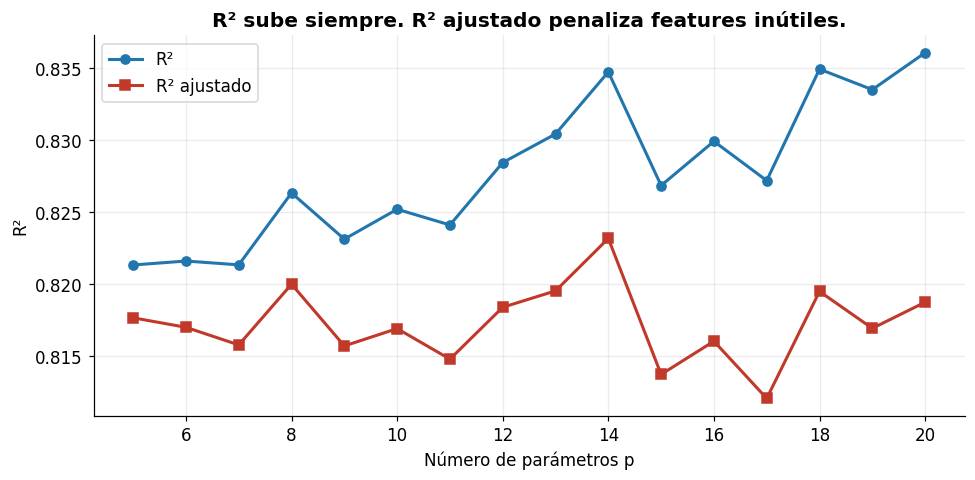

Usar siempre R²_adj para comparar modelos con distinto número de features.


In [4]:
# Demostrar que R²_adj penaliza features inútiles
np.random.seed(SEED)
r2_vals, r2adj_vals, p_vals = [], [], []

for extra in range(0, 16):   # agregar hasta 15 features de ruido
    p_curr = p + extra
    if extra == 0:
        X_curr = X.copy()
    else:
        ruido = np.random.randn(n, extra)
        X_curr = np.column_stack([X, ruido])
    b_c, *_ = np.linalg.lstsq(X_curr, y, rcond=None)
    yh_c    = X_curr @ b_c
    ec      = y - yh_c
    SSE_c   = (ec**2).sum()
    R2_c    = 1 - SSE_c/SST
    R2adj_c = 1 - (SSE_c/(n-p_curr))/(SST/(n-1))
    r2_vals.append(R2_c); r2adj_vals.append(R2adj_c); p_vals.append(p_curr)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(p_vals, r2_vals,    'o-', color='#2176AE', lw=2, label='R²')
ax.plot(p_vals, r2adj_vals, 's-', color='#C0392B', lw=2, label='R² ajustado')
ax.set_xlabel('Número de parámetros p')
ax.set_ylabel('R²')
ax.set_title('R² sube siempre. R² ajustado penaliza features inútiles.', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()
print('Usar siempre R²_adj para comparar modelos con distinto número de features.')

---
## 3. Prueba F Global

**H₀:** β₁ = β₂ = ⋯ = βₚ₋₁ = 0 (ninguna feature explica y)
**H₁:** al menos un βⱼ ≠ 0

$$F = \frac{MSR}{MSE} = \frac{SSR/(p-1)}{SSE/(n-p)} \sim F_{p-1,\, n-p}$$

Estadístico F = 224.1015
p-valor       = 0.000000

Conclusion: Rechazamos H₀: el modelo tiene poder explicativo


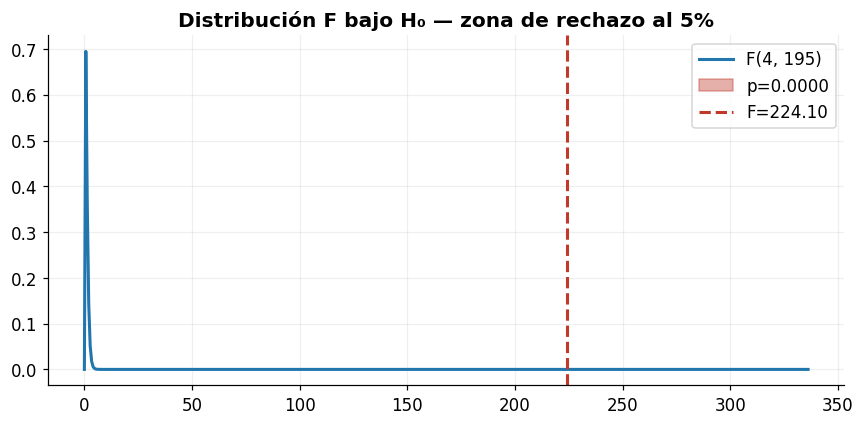

In [5]:
F_stat = MSR / MSE
p_val_F = 1 - stats.f.cdf(F_stat, df_reg, df_res)

print(f'Estadístico F = {F_stat:.4f}')
print(f'p-valor       = {p_val_F:.6f}')
print(f'\nConclusion: {"Rechazamos H₀: el modelo tiene poder explicativo" if p_val_F < 0.05 else "No rechazamos H₀"}')

# Visualizar la distribución F
x_f = np.linspace(0, max(F_stat*1.5, 5), 500)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_f, stats.f.pdf(x_f, df_reg, df_res), color='#2176AE', lw=2,
        label=f'F({df_reg}, {df_res})')
ax.fill_between(x_f, stats.f.pdf(x_f, df_reg, df_res),
                where=x_f >= F_stat, alpha=0.4, color='#C0392B', label=f'p={p_val_F:.4f}')
ax.axvline(F_stat, color='#C0392B', lw=2, linestyle='--', label=f'F={F_stat:.2f}')
ax.set_title('Distribución F bajo H₀ — zona de rechazo al 5%', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

---
## 4. t-tests para cada βⱼ

**H₀:** βⱼ = 0 (esa feature no aporta dado el resto)

$$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)} = \frac{\hat{\beta}_j}{s\sqrt{(\mathbf{X}^\top\mathbf{X})^{-1}_{jj}}} \sim t_{n-p}$$

In [6]:
XtX_inv = np.linalg.inv(X.T @ X)
s2_est  = SSE / df_res      # MSE = s²

# Error estándar de cada β̂ⱼ
SE_beta  = np.sqrt(s2_est * np.diag(XtX_inv))
t_stats  = beta_hat / SE_beta
p_vals_t = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=df_res))

# Intervalo de confianza al 95%
t_crit  = stats.t.ppf(0.975, df=df_res)
CI_lower = beta_hat - t_crit * SE_beta
CI_upper = beta_hat + t_crit * SE_beta

# Tabla de resultados
nombres  = ['intercepto', 'x1', 'x2', 'x3', 'x4']
tabla = pd.DataFrame({
    'Feature':    nombres,
    'β_real':     beta_true,
    'β̂':          beta_hat.round(4),
    'SE(β̂)':      SE_beta.round(4),
    't-stat':     t_stats.round(4),
    'p-valor':    p_vals_t.round(4),
    'IC_lower':   CI_lower.round(4),
    'IC_upper':   CI_upper.round(4),
    'Signif.':    ['***' if p < 0.001 else '**' if p < 0.01
                   else '*' if p < 0.05 else '.' for p in p_vals_t],
})
print('Tabla de coeficientes:')
print(tabla.to_string(index=False))

Tabla de coeficientes:
   Feature  β_real      β̂  SE(β̂)   t-stat  p-valor  IC_lower  IC_upper Signif.
intercepto    10.0 10.2565  0.1359  75.4856   0.0000    9.9885   10.5245     ***
        x1     3.0  3.1192  0.1367  22.8243   0.0000    2.8497    3.3887     ***
        x2    -1.5 -1.6408  0.1370 -11.9774   0.0000   -1.9110   -1.3707     ***
        x3     2.0  2.0011  0.1362  14.6926   0.0000    1.7325    2.2697     ***
        x4     0.5  0.4878  0.1366   3.5695   0.0005    0.2183    0.7573     ***


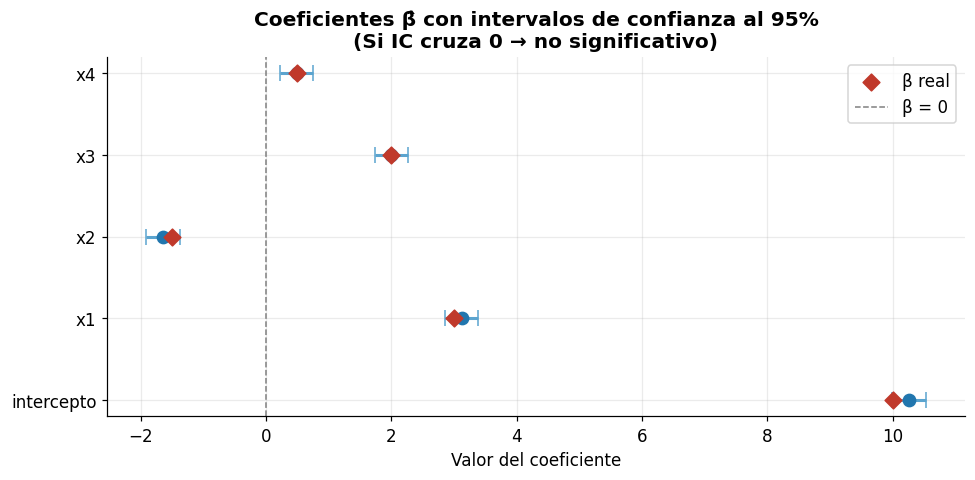

In [7]:
# Visualizar coeficientes con IC al 95%
fig, ax = plt.subplots(figsize=(9, 4.5))
y_pos = range(len(nombres))
ax.errorbar(beta_hat, y_pos,
            xerr=[beta_hat - CI_lower, CI_upper - beta_hat],
            fmt='o', color='#2176AE', ecolor='#5BA4CF', capsize=5,
            markersize=8, linewidth=2)
ax.scatter(beta_true, y_pos, marker='D', color='#C0392B', s=60, zorder=5,
           label='β real')
ax.axvline(0, color='gray', lw=1, linestyle='--', label='β = 0')
ax.set_yticks(list(y_pos)); ax.set_yticklabels(nombres)
ax.set_xlabel('Valor del coeficiente')
ax.set_title('Coeficientes β̂ con intervalos de confianza al 95%\n(Si IC cruza 0 → no significativo)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

---
## 5. Reporte de regresión completo

Construimos una función `ols_summary()` que genera un reporte tipo `statsmodels`.

In [8]:
def ols_summary(X, y, feature_names=None):
    """
    Reporte completo de regresión OLS.
    Incluye: R², R²_adj, F-test, tabla de coeficientes con t-tests e IC.
    """
    n, p = X.shape
    names = feature_names or [f'x{i}' for i in range(p)]

    # Estimación
    beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta_hat
    e     = y - y_hat

    # Sumas de cuadrados
    y_bar = y.mean()
    SST   = ((y - y_bar)**2).sum()
    SSE   = (e**2).sum()
    SSR   = SST - SSE
    df_r  = p - 1; df_e  = n - p; df_t = n - 1
    MSR   = SSR / df_r; MSE  = SSE / df_e
    s2    = MSE; s    = np.sqrt(s2)

    # Métricas
    R2    = 1 - SSE/SST
    R2adj = 1 - (SSE/df_e)/(SST/df_t)
    F     = MSR / MSE
    pF    = 1 - stats.f.cdf(F, df_r, df_e)

    # Inferencia
    XtX_inv = np.linalg.inv(X.T @ X)
    SE      = np.sqrt(s2 * np.diag(XtX_inv))
    t_st    = beta_hat / SE
    p_t     = 2 * (1 - stats.t.cdf(np.abs(t_st), df=df_e))
    t_crit  = stats.t.ppf(0.975, df=df_e)
    lo      = beta_hat - t_crit * SE
    hi      = beta_hat + t_crit * SE

    # Imprimir
    sep = '═'*64
    print(sep)
    print('  RESUMEN DE REGRESIÓN OLS')
    print(sep)
    print(f'  Observaciones: {n}   Parámetros: {p}')
    print(f'  R²:       {R2:.4f}     R² ajustado: {R2adj:.4f}')
    print(f'  s (RMSE): {s:.4f}     SSE:         {SSE:.4f}')
    print(f'  F({df_r},{df_e}):   {F:.4f}     p-valor F:   {pF:.4e}')
    print(sep)
    print(f'  {"Feature":14s} {"β̂":>9s} {"SE":>9s} {"t":>9s} {"p-valor":>10s}  IC 95%')
    print('─'*64)
    for i, nm in enumerate(names):
        sig = '***' if p_t[i]<0.001 else '**' if p_t[i]<0.01 else '*' if p_t[i]<0.05 else ''
        print(f'  {nm:14s} {beta_hat[i]:>9.4f} {SE[i]:>9.4f} {t_st[i]:>9.4f}'
              f' {p_t[i]:>10.4f}  [{lo[i]:.3f}, {hi[i]:.3f}] {sig}')
    print(sep)
    print('  Signif: *** p<0.001  ** p<0.01  * p<0.05')
    print(sep)
    return {'beta':beta_hat,'SE':SE,'t':t_st,'p':p_t,'R2':R2,'R2adj':R2adj,
            'F':F,'pF':pF,'s2':s2,'lo':lo,'hi':hi}

feat_names = ['intercepto','edad','ingresos','deuda','productos']
res = ols_summary(X, y, feature_names=['intercepto','x1','x2','x3','x4'])

════════════════════════════════════════════════════════════════
  RESUMEN DE REGRESIÓN OLS
════════════════════════════════════════════════════════════════
  Observaciones: 200   Parámetros: 5
  R²:       0.8213     R² ajustado: 0.8177
  s (RMSE): 1.9215     SSE:         720.0036
  F(4,195):   224.1015     p-valor F:   0.0000e+00
════════════════════════════════════════════════════════════════
  Feature               β̂        SE         t    p-valor  IC 95%
────────────────────────────────────────────────────────────────
  intercepto       10.2565    0.1359   75.4856     0.0000  [9.989, 10.524] ***
  x1                3.1192    0.1367   22.8243     0.0000  [2.850, 3.389] ***
  x2               -1.6408    0.1370  -11.9774     0.0000  [-1.911, -1.371] ***
  x3                2.0011    0.1362   14.6926     0.0000  [1.732, 2.270] ***
  x4                0.4878    0.1366    3.5695     0.0005  [0.218, 0.757] ***
════════════════════════════════════════════════════════════════
  Signif: ***

---
## 6. Aplicación: Tabla de regresión para predicción de salarios

Generamos un caso de negocio realista y producimos el reporte completo.

In [9]:
# Dataset: predicción de salarios
np.random.seed(SEED)
n_sal = 400
experiencia  = np.random.uniform(0, 30, n_sal)
educacion    = np.random.choice([12,16,18,22], n_sal).astype(float)
sector_tech  = (np.random.rand(n_sal) > 0.6).astype(float)
gestion      = np.random.uniform(0, 15, n_sal)

salario = (30_000
           + 2_000 * experiencia
           + 3_500 * educacion
           + 12_000 * sector_tech
           + 1_500 * gestion
           + np.random.normal(0, 8_000, n_sal))

feats_sal = ['experiencia','educacion','sector_tech','gestion']
X_sal_raw = np.column_stack([experiencia, educacion, sector_tech, gestion])
X_sal = np.column_stack([np.ones(n_sal),
                          StandardScaler().fit_transform(X_sal_raw)])

print('Dataset de salarios:')
print(f'  n={n_sal}, features: {feats_sal}')
print(f'  Salario promedio: {salario.mean():,.0f} USD')
print(f'  Rango: [{salario.min():,.0f}, {salario.max():,.0f}] USD\n')

res_sal = ols_summary(X_sal, salario,
                       feature_names=['intercepto']+feats_sal)

Dataset de salarios:
  n=400, features: ['experiencia', 'educacion', 'sector_tech', 'gestion']
  Salario promedio: 134,317 USD
  Rango: [76,051, 199,542] USD

════════════════════════════════════════════════════════════════
  RESUMEN DE REGRESIÓN OLS
════════════════════════════════════════════════════════════════
  Observaciones: 400   Parámetros: 5
  R²:       0.8963     R² ajustado: 0.8953
  s (RMSE): 7990.2694     SSE:         25218539816.1084
  F(4,395):   853.5938     p-valor F:   0.0000e+00
════════════════════════════════════════════════════════════════
  Feature               β̂        SE         t    p-valor  IC 95%
────────────────────────────────────────────────────────────────
  intercepto     134316.7738  399.5135  336.2009     0.0000  [133531.335, 135102.212] ***
  experiencia    17069.8680  402.3392   42.4266     0.0000  [16278.874, 17860.862] ***
  educacion      12563.4018  400.2238   31.3909     0.0000  [11776.567, 13350.237] ***
  sector_tech    6218.6816  405.7965 

In [10]:
# Predicción para nuevos empleados
nuevos_sal = np.array([
    [10, 16, 0, 5],   # empleado A: 10 años exp, educación 16, no tech, 5 años gestión
    [5,  22, 1, 2],   # empleado B: junior, master, sector tech
    [25, 12, 0, 15],  # empleado C: senior, bachillerato, gestión
])

scaler_sal = StandardScaler().fit(X_sal_raw)
X_pred = np.column_stack([np.ones(3), scaler_sal.transform(nuevos_sal)])
beta_sal, *_ = np.linalg.lstsq(X_sal, salario, rcond=None)
pred_sal = X_pred @ beta_sal

# IC para predicción de la media
XtX_sal_inv = np.linalg.inv(X_sal.T @ X_sal)
s2_sal = ((salario - X_sal @ beta_sal)**2).sum() / (n_sal - X_sal.shape[1])
SE_pred = np.sqrt(s2_sal * np.array([x @ XtX_sal_inv @ x for x in X_pred]))
t_crit_sal = stats.t.ppf(0.975, df=n_sal - X_sal.shape[1])

print('Predicciones de salario con IC al 95%:')
labels_emp = ['A (10y exp, no tech)','B (junior, tech)','C (senior, no tech)']
for i, (lbl, pred, se) in enumerate(zip(labels_emp, pred_sal, SE_pred)):
    lo_p, hi_p = pred - t_crit_sal*se, pred + t_crit_sal*se
    print(f'  {lbl}: {pred:,.0f} USD  IC: [{lo_p:,.0f}, {hi_p:,.0f}]')

Predicciones de salario con IC al 95%:
  A (10y exp, no tech): 113,970 USD  IC: [112,828, 115,112]
  B (junior, tech): 133,391 USD  IC: [131,134, 135,647]
  C (senior, no tech): 144,755 USD  IC: [142,648, 146,862]


---
## Conclusiones

<div style="background:#EAF2FB;border-left:5px solid #2176AE;padding:20px 24px;border-radius:0 8px 8px 0;">

**01 · R² ajustado para comparar modelos**  
R² siempre sube al agregar features. R²_adj penaliza la complejidad. Siempre reportar ambos.

**02 · F-test primero, luego t-tests**  
Si el F-test no rechaza H₀, ningún β̂ᵢ es significativo individualmente — no mirar los t-tests.

**03 · Los IC son más informativos que los p-valores**  
Un IC al 95% que no cruce 0 equivale a rechazo al 5%. Pero además da el rango plausible de β.

</div>

---
<div style="background:#0F3D6E;color:white;padding:20px 24px;border-radius:8px;">
<strong>Fin del Módulo 1 — Regresión Lineal completado ✓</strong><br>
Próximo: Módulo 2 — Regresión Logística (Formulación desde el GLM)<br>
<em>Docente: Josef Rodriguez · Curso 8 · Modelos Estadísticos</em>
</div>